# LSTM Evaluate (Multi-Class)
Evaluates the LSTM model on 3 classes: Healthy, Inter-ictal, Seizure.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    classification_report
)

sns.set(style="whitegrid")

In [2]:
output_dir = "../outputs"
y_true = np.load(os.path.join(output_dir, "lstm_y_test_true.npy"))
y_pred = np.load(os.path.join(output_dir, "lstm_y_test_pred.npy"))

print(f"Loaded {len(y_true)} test samples.")

Loaded 13200 test samples.


In [3]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall: {recall:.4f}")
print(f"Macro F1-Score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Healthy', 'Inter-ictal', 'Seizure']))

Accuracy: 0.9343
Macro Precision: 0.9396
Macro Recall: 0.9414
Macro F1-Score: 0.9399

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.91      0.95      0.93      5280
 Inter-ictal       0.95      0.89      0.92      5280
     Seizure       0.96      0.98      0.97      2640

    accuracy                           0.93     13200
   macro avg       0.94      0.94      0.94     13200
weighted avg       0.94      0.93      0.93     13200



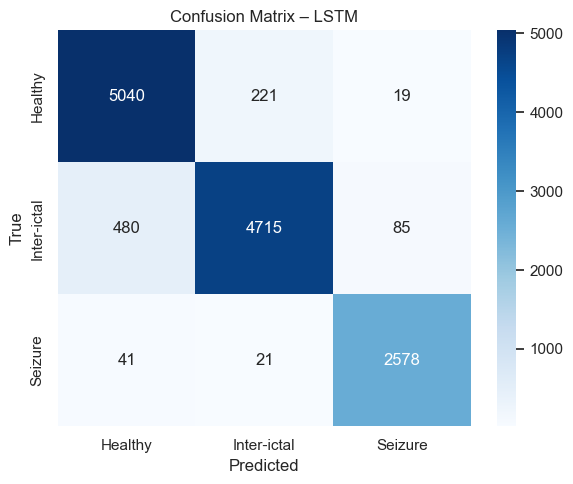

In [4]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Healthy", "Inter-ictal", "Seizure"],
    yticklabels=["Healthy", "Inter-ictal", "Seizure"]
)
plt.title("Confusion Matrix – LSTM")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [5]:
metrics_data = {
    "model": "LSTM",
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "confusion_matrix": cm.tolist()
}

metrics_dir = "../metrics"
os.makedirs(metrics_dir, exist_ok=True)

file_path = os.path.join(metrics_dir, "LSTM_metrics.json")
with open(file_path, "w") as f:
    json.dump(metrics_data, f, indent=4)

print(f"Metrics saved to {file_path}")

Metrics saved to ../metrics/LSTM_metrics.json


## AUC-ROC Curves

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Binarize the output
y_test_bin = label_binarize(y_true, classes=[0, 1, 2])
y_score = y_pred_proba  # Make sure this is loaded!
n_classes = y_test_bin.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot of a ROC curve for a specific class
plt.figure(figsize=(10, 8))
colors = ['aqua', 'darkorange', 'cornflowerblue']
classes = ['Healthy (0)', 'Inter-ictal (1)', 'Seizure (2)']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(classes[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver operating characteristic to multi-class - {model_name}')
plt.legend(loc="lower right")
plt.show()

metrics_data["auc"] = roc_auc
